Import Libraries

In [1]:
# These are tools we use for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

print("All libraries loaded successfully!")

All libraries loaded successfully!


Load Datasets

In [2]:
# Load Dataset 1
df1 = pd.read_csv('Credit_Card_Dataset_2025_Sept_1.csv')

# Load Dataset 2
df2 = pd.read_csv('Credit_Card_Dataset_2025_Sept_2.csv')

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)
print()
print("Dataset 1 columns:", list(df1.columns))
print("Dataset 2 columns:", list(df2.columns))
print()
print("Both datasets loaded successfully!")

Dataset 1 shape: (25134, 17)
Dataset 2 shape: (25134, 4)

Dataset 1 columns: ['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']
Dataset 2 columns: ['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']

Both datasets loaded successfully!


Merge Datasets

In [3]:
# Connect Dataset 1 and Dataset 2 using ID column
# Dataset 1 has "ID", Dataset 2 has "User" - they are the same!
df = pd.merge(df1, df2, left_on='ID', right_on='User')

# Remove the extra 'User' column (same as ID)
df = df.drop(columns=['User', 'Unnamed: 0'])

print("Merged dataset shape:", df.shape)
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print()
print("Columns after merge:", list(df.columns))
print()
print("Datasets merged successfully!")

Merged dataset shape: (25134, 19)
Total rows: 25134
Total columns: 19

Columns after merge: ['ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET', 'INCOME', 'INCOME_TYPE', 'EDUCATION_TYPE']

Datasets merged successfully!


In [4]:
# Show first 5 rows - to see what data looks like
print("First 5 rows of merged dataset:")
df.head()

First 5 rows of merged dataset:


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,5008806,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,Secondary / secondary special
1,5008808,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
2,5008809,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
3,5008810,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
4,5008811,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special


In [5]:
# Show column names and their types (number or text)
print("Column names and data types:")
df.info()

Column names and data types:
<class 'pandas.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              25134 non-null  int64  
 1   GENDER          25134 non-null  str    
 2   CAR             25134 non-null  str    
 3   REALITY         25134 non-null  str    
 4   NO_OF_CHILD     25134 non-null  int64  
 5   FAMILY_TYPE     25134 non-null  str    
 6   HOUSE_TYPE      25134 non-null  str    
 7   FLAG_MOBIL      25134 non-null  int64  
 8   WORK_PHONE      25134 non-null  int64  
 9   PHONE           25134 non-null  int64  
 10  E_MAIL          25134 non-null  int64  
 11  FAMILY SIZE     25133 non-null  float64
 12  BEGIN_MONTH     25134 non-null  int64  
 13  AGE             25134 non-null  int64  
 14  YEARS_EMPLOYED  25125 non-null  float64
 15  TARGET          25134 non-null  int64  
 16  INCOME          25134 non-null  float64
 17  INCOME_TYPE  

Show unique values

In [6]:
print("Unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique values in each column:
ID: 25134 unique values
GENDER: 2 unique values
CAR: 2 unique values
REALITY: 2 unique values
NO_OF_CHILD: 9 unique values
FAMILY_TYPE: 5 unique values
HOUSE_TYPE: 6 unique values
FLAG_MOBIL: 1 unique values
WORK_PHONE: 2 unique values
PHONE: 2 unique values
E_MAIL: 2 unique values
FAMILY SIZE: 10 unique values
BEGIN_MONTH: 61 unique values
AGE: 50 unique values
YEARS_EMPLOYED: 43 unique values
TARGET: 2 unique values
INCOME: 195 unique values
INCOME_TYPE: 5 unique values
EDUCATION_TYPE: 5 unique values


Check Missing Values

In [7]:
# Check how many values are missing in each column
print("Missing values in each column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values in each column:
ID                 0
GENDER             0
CAR                0
REALITY            0
NO_OF_CHILD        0
FAMILY_TYPE        0
HOUSE_TYPE         0
FLAG_MOBIL         0
WORK_PHONE         0
PHONE              0
E_MAIL             0
FAMILY SIZE        1
BEGIN_MONTH        0
AGE                0
YEARS_EMPLOYED     9
TARGET             0
INCOME             0
INCOME_TYPE       12
EDUCATION_TYPE     0
dtype: int64

Total missing values: 22


## Basic Statistics 

In [8]:
# Show min, max, average of number columns
print("Basic Statistics:")
df.describe()

Basic Statistics:


,ID,NO_OF_CHILD,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME
count,2.513400e+04,25134.000000,25134.0,25134.000000,25134.000000,25134.000000,25133.000000,25134.000000,25134.000000,25125.000000,25134.000000,2.513400e+04
mean,5.078838e+06,0.512334,1.0,0.273812,0.292791,0.100660,2.294076,26.120594,40.589998,7.205214,0.016790,1.948339e+05
std,4.194102e+04,0.787785,0.0,0.445923,0.455052,0.300885,0.947607,16.439658,10.348136,6.415004,0.128486,1.045110e+05
min,5.008806e+06,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000,21.000000,0.000000,0.000000,2.700000e+04
25%,5.042228e+06,0.000000,1.0,0.000000,0.000000,0.000000,2.000000,12.000000,33.000000,3.000000,0.000000,1.350000e+05
50%,5.079004e+06,0.000000,1.0,0.000000,0.000000,0.000000,2.000000,24.000000,40.000000,5.000000,0.000000,1.800000e+05
75%,5.115604e+06,1.000000,1.0,1.000000,1.000000,0.000000,3.000000,39.000000,48.000000,10.000000,0.000000,2.250000e+05
max,5.150487e+06,19.000000,1.0,1.000000,1.000000,1.000000,20.000000,60.000000,450.000000,43.000000,1.000000,1.575000e+06


Fraud Count

TARGET column distribution:
0 = Normal transaction
1 = Fraud transaction

TARGET
0    24712
1      422
Name: count, dtype: int64

Fraud percentage: 1.68 %


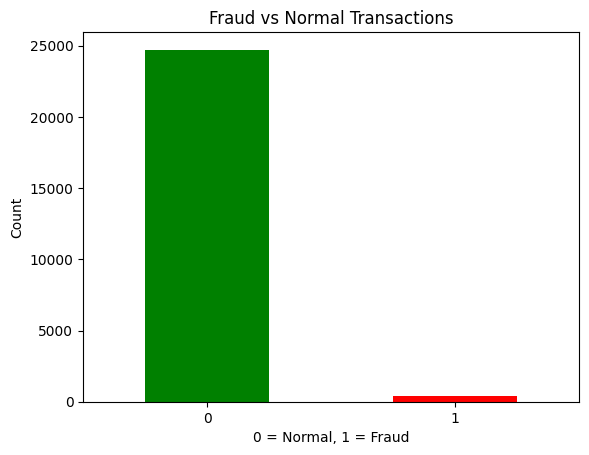

In [9]:
# Check fraud vs normal distribution
print("TARGET column distribution:")
print("0 = Normal transaction")
print("1 = Fraud transaction")
print()
print(df['TARGET'].value_counts())
print()
print("Fraud percentage:", round(df['TARGET'].mean() * 100, 2), "%")

# Draw chart
df['TARGET'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Fraud vs Normal Transactions')
plt.xlabel('0 = Normal, 1 = Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

 Fix Missing Values in Number Columns

In [10]:
# For number columns - fill missing values with AVERAGE
number_columns = ['NO_OF_CHILD', 'INCOME', 'AGE',
                  'YEARS_EMPLOYED', 'FAMILY SIZE']

for col in number_columns:
    missing = df[col].isnull().sum()
    df[col] = df[col].fillna(df[col].mean())
    print(f"{col}: Fixed {missing} missing values with mean = {round(df[col].mean(), 2)}")

print()
print("Number columns - missing values fixed!")

NO_OF_CHILD: Fixed 0 missing values with mean = 0.51
INCOME: Fixed 0 missing values with mean = 194833.85
AGE: Fixed 0 missing values with mean = 40.59
YEARS_EMPLOYED: Fixed 9 missing values with mean = 7.21
FAMILY SIZE: Fixed 1 missing values with mean = 2.29

Number columns - missing values fixed!


Fix Missing Values in Text Columns

In [11]:
# For text columns - fill with MOST COMMON value
text_columns = ['GENDER', 'CAR', 'REALITY', 'INCOME_TYPE',
                'EDUCATION_TYPE', 'FAMILY_TYPE', 'HOUSE_TYPE']

for col in text_columns:
    missing = df[col].isnull().sum()
    df[col] = df[col].fillna(df[col].mode()[0])
    print(f"{col}: Fixed {missing} missing values with mode = {df[col].mode()[0]}")

print()
print("Text columns - missing values fixed!")

GENDER: Fixed 0 missing values with mode = F
CAR: Fixed 0 missing values with mode = N
REALITY: Fixed 0 missing values with mode = Y
INCOME_TYPE: Fixed 12 missing values with mode = Working
EDUCATION_TYPE: Fixed 0 missing values with mode = Secondary / secondary special
FAMILY_TYPE: Fixed 0 missing values with mode = Married
HOUSE_TYPE: Fixed 0 missing values with mode = House / apartment

Text columns - missing values fixed!


Remove Duplicates

In [12]:
# Step 3: Remove duplicate rows
print("Before removing duplicates:", df.shape[0], "rows")
df = df.drop_duplicates()
print("After removing duplicates:", df.shape[0], "rows")
print()

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print()
print("Data cleaning COMPLETE!")

Before removing duplicates: 25134 rows
After removing duplicates: 25134 rows

Missing values after cleaning:
ID                0
GENDER            0
CAR               0
REALITY           0
NO_OF_CHILD       0
FAMILY_TYPE       0
HOUSE_TYPE        0
FLAG_MOBIL        0
WORK_PHONE        0
PHONE             0
E_MAIL            0
FAMILY SIZE       0
BEGIN_MONTH       0
AGE               0
YEARS_EMPLOYED    0
TARGET            0
INCOME            0
INCOME_TYPE       0
EDUCATION_TYPE    0
dtype: int64

Data cleaning COMPLETE!


Chart 2: Gender Distribution

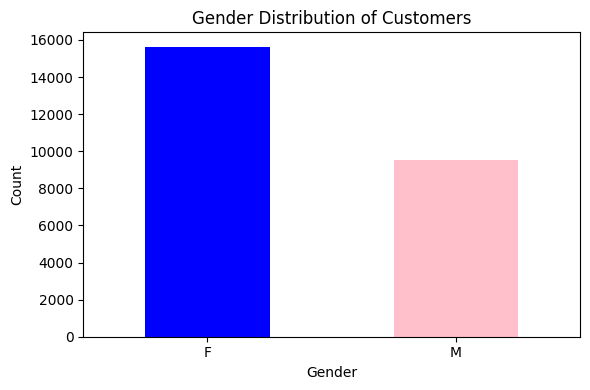

Gender distribution:
GENDER
F    15630
M     9504
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6,4))
df['GENDER'].value_counts().plot(kind='bar', color=['blue','pink'])
plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Gender distribution:")
print(df['GENDER'].value_counts())

Chart 3: Age Distribution

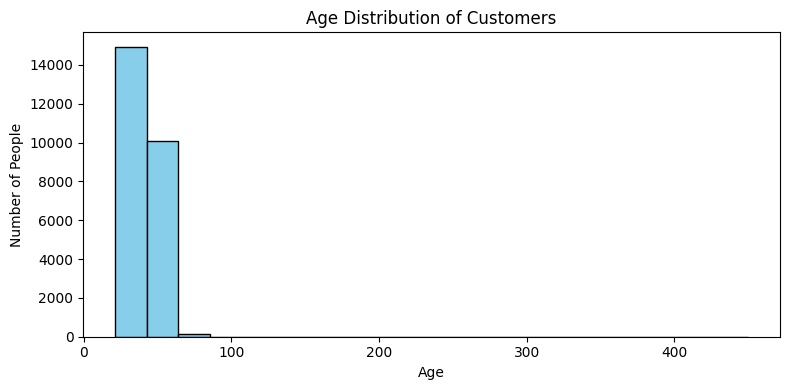

Age statistics:
Average age: 40.6
Youngest: 21
Oldest: 450


In [14]:
plt.figure(figsize=(8,4))
plt.hist(df['AGE'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.tight_layout()
plt.show()

print("Age statistics:")
print("Average age:", round(df['AGE'].mean(), 1))
print("Youngest:", df['AGE'].min())
print("Oldest:", df['AGE'].max())

Chart 4: Income Distribution

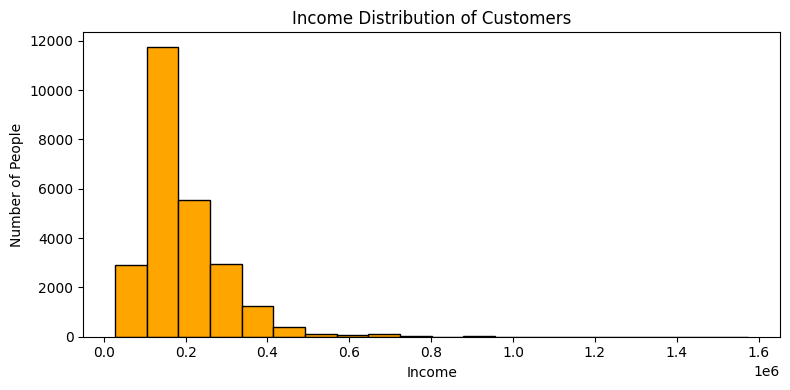

Income statistics:
Average income: 194833.9
Min income: 27000.0
Max income: 1575000.0


In [15]:
plt.figure(figsize=(8,4))
plt.hist(df['INCOME'], bins=20, color='orange', edgecolor='black')
plt.title('Income Distribution of Customers')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.tight_layout()
plt.show()

print("Income statistics:")
print("Average income:", round(df['INCOME'].mean(), 1))
print("Min income:", df['INCOME'].min())
print("Max income:", df['INCOME'].max())

Chart 5: Education Type

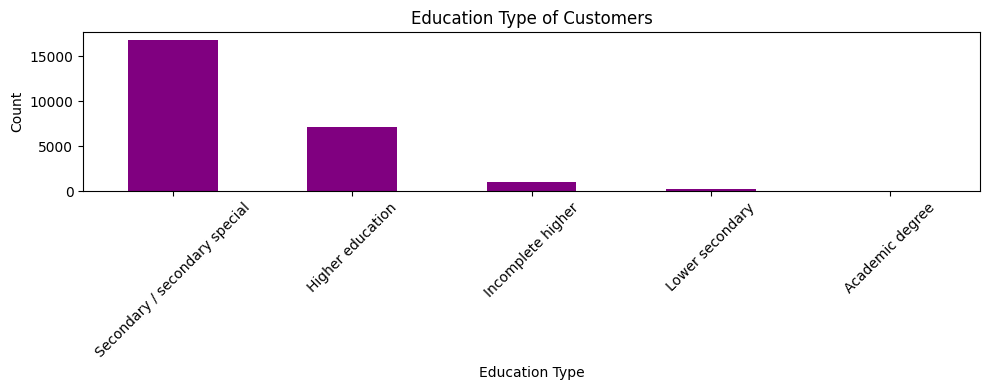

In [16]:
plt.figure(figsize=(10,4))
df['EDUCATION_TYPE'].value_counts().plot(kind='bar', color='purple')
plt.title('Education Type of Customers')
plt.xlabel('Education Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Chart 6: Fraud by Gender

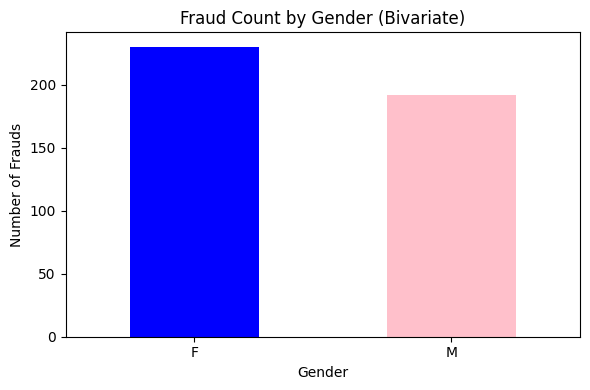

Fraud by gender:
GENDER
F    230
M    192
Name: TARGET, dtype: int64


In [17]:
plt.figure(figsize=(6,4))
fraud_gender = df.groupby('GENDER')['TARGET'].sum()
fraud_gender.plot(kind='bar', color=['blue','pink'])
plt.title('Fraud Count by Gender (Bivariate)')
plt.xlabel('Gender')
plt.ylabel('Number of Frauds')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Fraud by gender:")
print(fraud_gender)

Income by Fraud (Bivariate Analysis)

<Figure size 800x400 with 0 Axes>

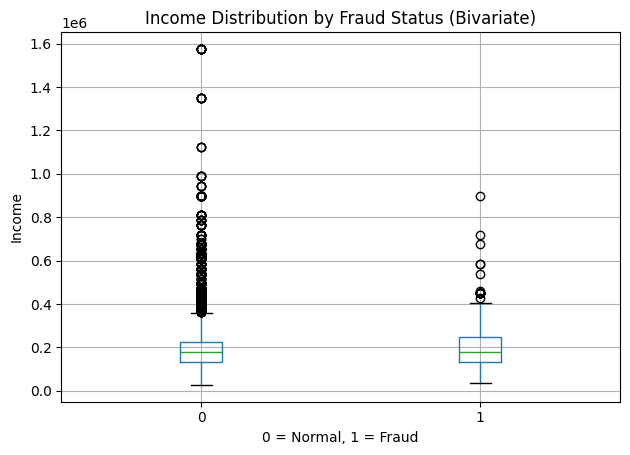

In [18]:
plt.figure(figsize=(8,4))
df.boxplot(column='INCOME', by='TARGET')
plt.title('Income Distribution by Fraud Status (Bivariate)')
plt.suptitle('')
plt.xlabel('0 = Normal, 1 = Fraud')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

Fraud by Income Type (Multivariate Analysis)

<Figure size 1200x500 with 0 Axes>

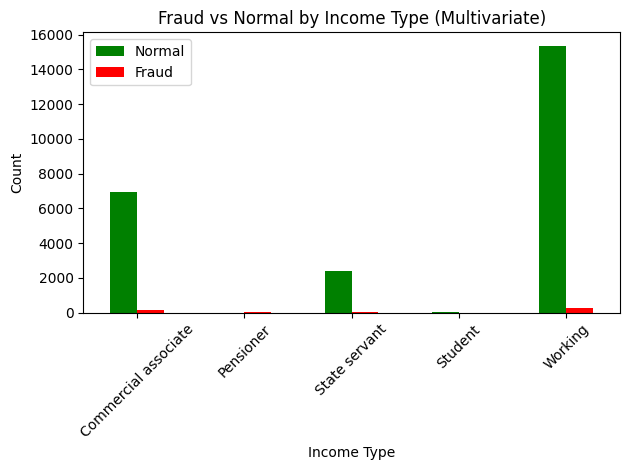

In [19]:
plt.figure(figsize=(12,5))
fraud_income = df.groupby(['INCOME_TYPE', 'TARGET']).size().unstack()
fraud_income.plot(kind='bar', color=['green','red'])
plt.title('Fraud vs Normal by Income Type (Multivariate)')
plt.xlabel('Income Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(['Normal', 'Fraud'])
plt.tight_layout()
plt.show()

Chart 7: Correlation Heatmap

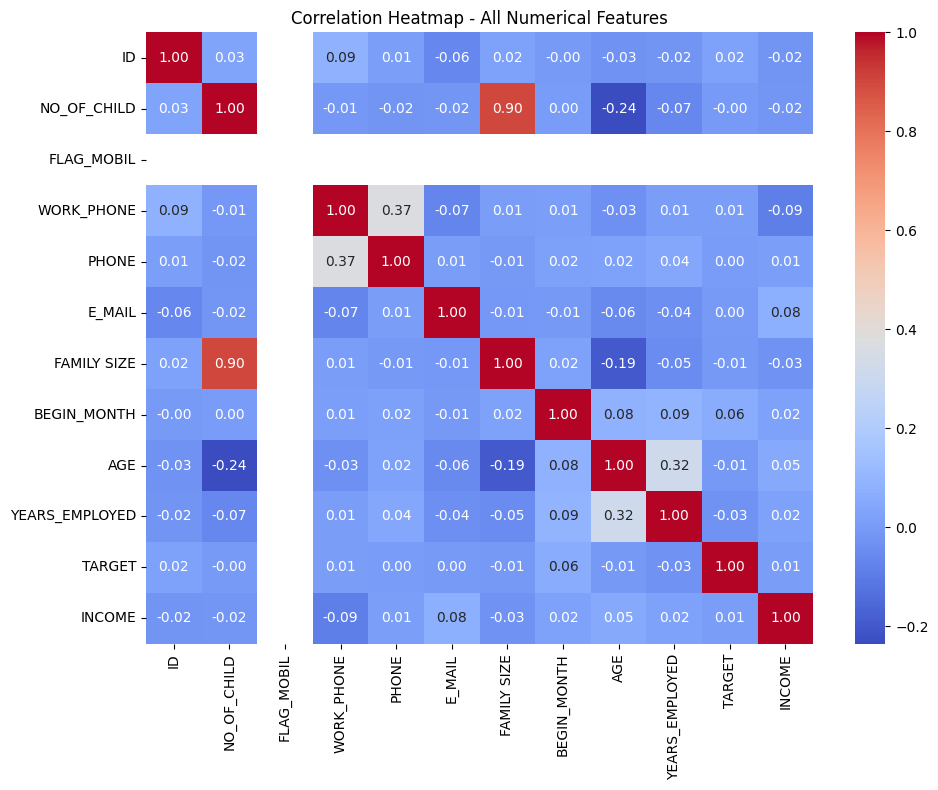

Interpretation:
Values close to 1 or -1 = strong relationship
Values close to 0 = no relationship


In [20]:
plt.figure(figsize=(10,8))
number_cols = df.select_dtypes(include='number')
sns.heatmap(number_cols.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm')
plt.title('Correlation Heatmap - All Numerical Features')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("Values close to 1 or -1 = strong relationship")
print("Values close to 0 = no relationship")

## Statistical Summary

In [21]:
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print()
print("Total transactions:", df.shape[0])
print("Total features:", df.shape[1])
print("Fraud transactions:", sum(df['TARGET'] == 1))
print("Normal transactions:", sum(df['TARGET'] == 0))
print("Fraud percentage:", round(df['TARGET'].mean() * 100, 2), "%")
print()
print("Numerical features summary:")
print(df.describe().round(2))

STATISTICAL SUMMARY

Total transactions: 25134
Total features: 19
Fraud transactions: 422
Normal transactions: 24712
Fraud percentage: 1.68 %

Numerical features summary:
               ID  NO_OF_CHILD  FLAG_MOBIL  WORK_PHONE     PHONE   E_MAIL  \
count    25134.00     25134.00     25134.0    25134.00  25134.00  25134.0   
mean   5078837.56         0.51         1.0        0.27      0.29      0.1   
std      41941.02         0.79         0.0        0.45      0.46      0.3   
min    5008806.00         0.00         1.0        0.00      0.00      0.0   
25%    5042228.25         0.00         1.0        0.00      0.00      0.0   
50%    5079004.00         0.00         1.0        0.00      0.00      0.0   
75%    5115603.75         1.00         1.0        1.00      1.00      0.0   
max    5150487.00        19.00         1.0        1.00      1.00      1.0   

       FAMILY SIZE  BEGIN_MONTH       AGE  YEARS_EMPLOYED    TARGET  \
count     25134.00     25134.00  25134.00        25134.00  25134

### Model Building

In [22]:
# ML models only understand numbers not text!
df_ml = df.copy()

text_columns = ['GENDER', 'CAR', 'REALITY', 'INCOME_TYPE',
                'EDUCATION_TYPE', 'FAMILY_TYPE', 'HOUSE_TYPE']

for col in text_columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])

print("Text columns converted to numbers!")
print()
print("First 5 rows after encoding:")
df_ml.head()

Text columns converted to numbers!

First 5 rows after encoding:


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,5008806,1,1,1,0,1,1,1,0,0,0,2.0,29,59,3.0,0,112500.0,4,4
1,5008808,0,0,1,0,3,1,1,0,1,1,1.0,4,52,8.0,0,270000.0,0,4
2,5008809,0,0,1,0,3,1,1,0,1,1,1.0,26,52,8.0,0,270000.0,0,4
3,5008810,0,0,1,0,3,1,1,0,1,1,1.0,26,52,8.0,0,270000.0,0,4
4,5008811,0,0,1,0,3,1,1,0,1,1,1.0,38,52,8.0,0,270000.0,0,4


Split X and y

In [23]:
# Step 2: Separate inputs (X) and output (y)
X = df_ml.drop(columns=['TARGET', 'ID'])
y = df_ml['TARGET']

print("Input features (X):", X.shape)
print("Output target (y):", y.shape)
print()
print("Feature columns:", list(X.columns))
print()
print("Class distribution:")
print("Normal (0):", sum(y == 0))
print("Fraud  (1):", sum(y == 1))

Input features (X): (25134, 17)
Output target (y): (25134,)

Feature columns: ['GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'INCOME', 'INCOME_TYPE', 'EDUCATION_TYPE']

Class distribution:
Normal (0): 24712
Fraud  (1): 422


Split Train and Test

In [24]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0], "(80%)")
print("Testing rows :", X_test.shape[0], "(20%)")
print()
print("Training fraud count:", sum(y_train == 1))
print("Testing fraud count :", sum(y_test == 1))

Training rows: 20107 (80%)
Testing rows : 5027 (20%)

Training fraud count: 336
Testing fraud count : 86


 Scale Numbers

In [25]:
# Make all numbers in same range
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Scaling done!")
print("All numbers are now in same range!")

Scaling done!
All numbers are now in same range!


Apply SMOTE

In [26]:
# Fix imbalanced data problem!
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

print("Before SMOTE:")
print("Normal:", sum(y_train == 0))
print("Fraud :", sum(y_train == 1))
print()
print("After SMOTE:")
print("Normal:", sum(y_train_smote == 0))
print("Fraud :", sum(y_train_smote == 1))
print("Now balanced")

Before SMOTE:
Normal: 19771
Fraud : 336

After SMOTE:
Normal: 19771
Fraud : 19771
Now balanced


### Build Model 1 - Logistic Regression (ORIGINAL)

Model 1 Original (No SMOTE)

In [27]:
model1 = LogisticRegression(random_state=42, max_iter=1000)
model1.fit(X_train_sc, y_train)
y_pred1 = model1.predict(X_test_sc)

print("=" * 50)
print("MODEL 1 - LOGISTIC REGRESSION (ORIGINAL)")
print("Without SMOTE improvement")
print("=" * 50)
print("Accuracy:", round(accuracy_score(y_test, y_pred1) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred1, zero_division=0))
print("Note: Fraud recall = 0 means model finds NO fraud!")

MODEL 1 - LOGISTIC REGRESSION (ORIGINAL)
Without SMOTE improvement
Accuracy: 98.29 %

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4941
           1       0.00      0.00      0.00        86

    accuracy                           0.98      5027
   macro avg       0.49      0.50      0.50      5027
weighted avg       0.97      0.98      0.97      5027

Note: Fraud recall = 0 means model finds NO fraud!


### Build Model 2 - Decision Tree (ORIGINAL)

Model 2 Original (No SMOTE)

In [28]:
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_sc, y_train)
y_pred2 = model2.predict(X_test_sc)

print("=" * 50)
print("MODEL 2 - DECISION TREE (ORIGINAL)")
print("Without SMOTE improvement")
print("=" * 50)
print("Accuracy:", round(accuracy_score(y_test, y_pred2) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred2, zero_division=0))

MODEL 2 - DECISION TREE (ORIGINAL)
Without SMOTE improvement
Accuracy: 96.92 %

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4941
           1       0.10      0.10      0.10        86

    accuracy                           0.97      5027
   macro avg       0.54      0.54      0.54      5027
weighted avg       0.97      0.97      0.97      5027



### Build Model 1 - Logistic Regression (IMPROVED)

 Model 1 Improved (With SMOTE)

In [29]:
model1_smote = LogisticRegression(random_state=42, max_iter=1000)
model1_smote.fit(X_train_smote, y_train_smote)
y_pred1_smote = model1_smote.predict(X_test_sc)

print("=" * 50)
print("MODEL 1 - LOGISTIC REGRESSION (IMPROVED)")
print("With SMOTE improvement")
print("=" * 50)
print("Accuracy:", round(accuracy_score(y_test, y_pred1_smote) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred1_smote, zero_division=0))
print("Note: Now model can detect fraud! Recall improved!")

MODEL 1 - LOGISTIC REGRESSION (IMPROVED)
With SMOTE improvement
Accuracy: 62.66 %

              precision    recall  f1-score   support

           0       0.99      0.63      0.77      4941
           1       0.03      0.63      0.05        86

    accuracy                           0.63      5027
   macro avg       0.51      0.63      0.41      5027
weighted avg       0.97      0.63      0.76      5027

Note: Now model can detect fraud! Recall improved!


### Build Model 2 - Decision Tree (IMPROVED)

Model 2 Improved (With SMOTE)

In [30]:
model2_smote = DecisionTreeClassifier(random_state=42)
model2_smote.fit(X_train_smote, y_train_smote)
y_pred2_smote = model2_smote.predict(X_test_sc)

print("=" * 50)
print("MODEL 2 - DECISION TREE (IMPROVED)")
print("With SMOTE improvement")
print("=" * 50)
print("Accuracy:", round(accuracy_score(y_test, y_pred2_smote) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred2_smote, zero_division=0))

MODEL 2 - DECISION TREE (IMPROVED)
With SMOTE improvement
Accuracy: 96.26 %

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4941
           1       0.12      0.19      0.15        86

    accuracy                           0.96      5027
   macro avg       0.55      0.58      0.56      5027
weighted avg       0.97      0.96      0.97      5027



### FINAL MODEL COMPARISON

Compare All 4 Models

In [31]:
acc1   = round(accuracy_score(y_test, y_pred1) * 100, 2)
acc2   = round(accuracy_score(y_test, y_pred2) * 100, 2)
acc1_s = round(accuracy_score(y_test, y_pred1_smote) * 100, 2)
acc2_s = round(accuracy_score(y_test, y_pred2_smote) * 100, 2)

print("=" * 55)
print("FINAL MODEL COMPARISON RESULTS")
print("=" * 55)
print("Logistic Regression (Original - No SMOTE) :", acc1, "%")
print("Decision Tree       (Original - No SMOTE) :", acc2, "%")
print("Logistic Regression (Improved - SMOTE)    :", acc1_s, "%")
print("Decision Tree       (Improved - SMOTE)    :", acc2_s, "%")
print("=" * 55)
print()
print("Best model:", "Logistic Regression (SMOTE)" if acc1_s > acc2_s else "Decision Tree (SMOTE)")
print()
print("Why conflicting results?")
print("High accuracy but low fraud recall = model ignores fraud!")
print("SMOTE fixes this by balancing the training data.")

FINAL MODEL COMPARISON RESULTS
Logistic Regression (Original - No SMOTE) : 98.29 %
Decision Tree       (Original - No SMOTE) : 96.92 %
Logistic Regression (Improved - SMOTE)    : 62.66 %
Decision Tree       (Improved - SMOTE)    : 96.26 %

Best model: Decision Tree (SMOTE)

Why conflicting results?
High accuracy but low fraud recall = model ignores fraud!
SMOTE fixes this by balancing the training data.


Final comparison chart

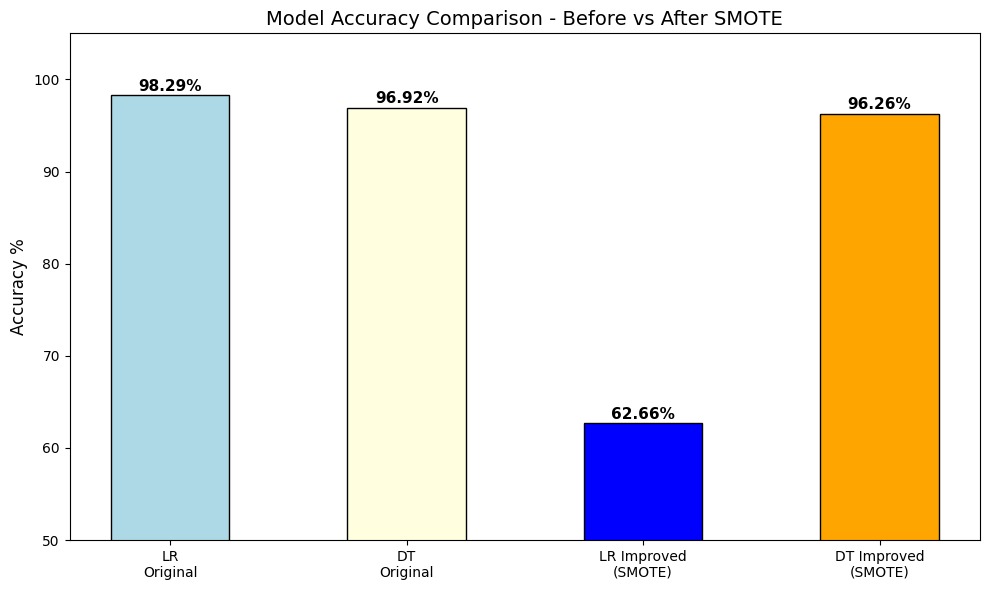

Blue bars = Original models (without SMOTE)
Dark bars = Improved models (with SMOTE)


In [32]:
plt.figure(figsize=(10,6))
models = ['LR\nOriginal', 'DT\nOriginal',
          'LR Improved\n(SMOTE)', 'DT Improved\n(SMOTE)']
accuracies = [acc1, acc2, acc1_s, acc2_s]
colors = ['lightblue', 'lightyellow', 'blue', 'orange']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
plt.title('Model Accuracy Comparison - Before vs After SMOTE', fontsize=14)
plt.ylabel('Accuracy %', fontsize=12)
plt.ylim([50, 105])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(acc) + '%',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Blue bars = Original models (without SMOTE)")
print("Dark bars = Improved models (with SMOTE)")